# A Chebyshev Toolbox: Doing Linear Algebra with Functions

> **Big Idea.** Polynomials of degree at most $n$ form an $(n+1)$-dimensional vector space. Once we fix a basis (Chebyshev) and a discretisation (the type-2 nodes), a function is a vector, integration is a linear functional, differentiation is a linear operator, and addition or scalar multiplication of functions is just addition or scalar multiplication of coefficient vectors. This notebook builds the half-dozen primitives that make that picture concrete, and then bolts them together into a tiny `Cheb` class.

We will implement, from scratch:

1. `polyfit` and `polyval` between values and Chebyshev coefficients via the DCT.
2. The 2nd barycentric formula for evaluation at arbitrary points.
3. Clenshaw-Curtis integration directly from coefficients.
4. Differentiation via the standard coefficient recurrence.
5. A simple sample-and-chop algorithm that decides how many coefficients to keep.

We keep things deliberately bare so the moving parts stay visible.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import dct

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 1. The grid: type-2 Chebyshev points

We use Chebyshev points of the *second kind*,
$$
x_k \;=\; \cos\!\left(\tfrac{k\pi}{n-1}\right), \qquad k=0,1,\ldots,n-1.
$$
These are the extrema of $T_{n-1}$ and include the endpoints $\pm 1$. We store them in increasing order from $-1$ to $+1$.

Computing them through `sin` (rather than `cos`) is more accurate near the endpoints, which is where Chebyshev points cluster.

In [2]:
def chebpts(n):
    """n type-2 Chebyshev points on [-1, 1], ordered x = -1 -> +1."""
    if n == 1:
        return np.array([0.0])
    return np.sin(np.pi * np.arange(-n + 1, n, 2) / (2.0 * (n - 1)))

x = chebpts(11)
print(x)

[-1.         -0.95105652 -0.80901699 -0.58778525 -0.30901699  0.
  0.30901699  0.58778525  0.80901699  0.95105652  1.        ]


## 2. The dictionary: values ↔ coefficients via the DCT

A degree-$(n-1)$ polynomial has two equally good descriptions:

- **Values** $f(x_k)$ at the $n$ Chebyshev points;
- **Coefficients** in the Chebyshev basis, $f(x) = \sum_{k=0}^{n-1} c_k T_k(x)$.

The map between them is a **discrete cosine transform of type I** (DCT-I). With type-2 nodes one finds, after a short calculation,
$$
f(x_j) \;=\; \sum_{k=0}^{n-1} c_k \cos\!\left(\tfrac{jk\pi}{n-1}\right),
$$
which is the DCT-I if we halve the boundary terms. The DCT runs in $O(n\log n)$, so converting between the two pictures is essentially free.

:::{note} Algorithm: polyfit and polyval (DCT version)

**polyfit($\mathbf{f}$):** values to coefficients.
1. Reverse $\mathbf{f}$ to standard ordering ($x_k = \cos(k\pi/(n-1))$).
2. Apply DCT-I.
3. Divide by $n-1$ and halve the first and last entries.

**polyval(c):** coefficients to values.
1. Halve the first and last entries of $c$.
2. Apply DCT-I.
3. Reverse to get $x = -1 \to +1$ ordering.
:::

(The DCT-I is its own inverse up to a scaling factor, which is what makes the two routines so symmetric.)

In [ ]:
def polyfit(f):
    """Values at type-2 Chebyshev points (-1 -> +1) -> Chebyshev coefficients."""
    f = np.asarray(f, dtype=float)
    n = f.size
    if n == 1:
        return f.copy()
    c = dct(f[::-1], type=1) / (n - 1)
    c[0] *= 0.5
    c[-1] *= 0.5
    return c


def polyval(c):
    """Chebyshev coefficients -> values at type-2 points (-1 -> +1)."""
    c = np.asarray(c, dtype=float)
    n = c.size
    if n == 1:
        return c.copy()
    a = c.copy()
    a[1:-1] *= 0.5
    return dct(a, type=1)[::-1]

In [ ]:
# Sanity check: the two maps are inverses of each other.
n = 32
x = chebpts(n)
f = np.exp(x)
c = polyfit(f)
f_back = polyval(c)
print(f"||polyval(polyfit(f)) - f||_inf = {np.max(np.abs(f_back - f)):.2e}")

# Sanity check: coefficients of T_3 should be e_3.
fT3 = 4 * x**3 - 3 * x
c_T3 = polyfit(fT3)
print(f"Chebyshev coefficients of T_3: {np.round(c_T3, 12)}")

### Aside: what the basis looks like

Before reading off coefficient decay, it helps to remember what the Chebyshev polynomials themselves look like. They are bounded by $1$ on $[-1,1]$, oscillate with $k+1$ extrema, and the equioscillation is the property that makes them near-optimal for polynomial approximation.

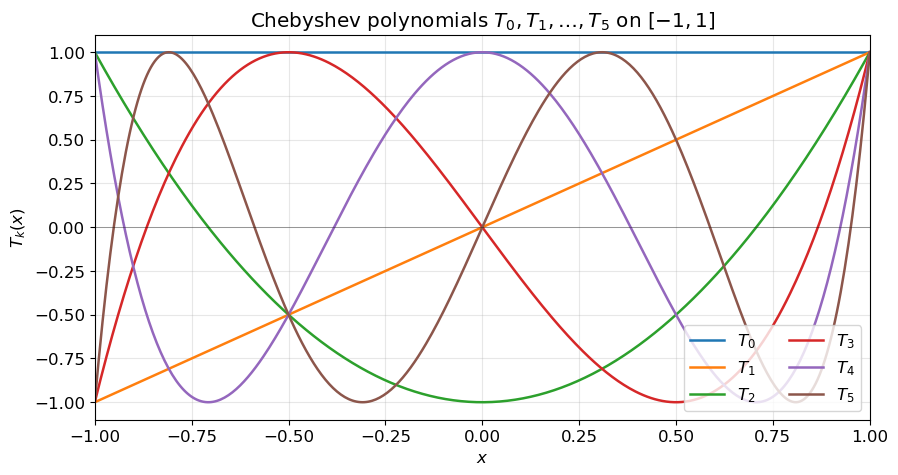

In [5]:
xx = np.linspace(-1, 1, 401)
fig, ax = plt.subplots(figsize=(10, 5))
for k in range(6):
    Tk = np.cos(k * np.arccos(xx))                    # T_k(x) = cos(k arccos x)
    ax.plot(xx, Tk, lw=1.8, label=f'$T_{k}$')
ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.set_xlabel('$x$')
ax.set_ylabel('$T_k(x)$')
ax.set_title('Chebyshev polynomials $T_0, T_1, \\ldots, T_5$ on $[-1, 1]$')
ax.set_xlim(-1, 1); ax.set_ylim(-1.1, 1.1)
ax.legend(loc='lower right', ncol=2)
ax.grid(True, alpha=0.3)
plt.show()

### Coefficient decay encodes smoothness

Once we have `polyfit`, the coefficients themselves are diagnostic. Smooth functions produce coefficients that drop off geometrically (analytic) or algebraically ($C^k$ but not $C^{k+1}$). This is the picture that drives the adaptive sampling we set up in §5.

In [ ]:
n = 129
x = chebpts(n)

tests = [
    ('exp(x), analytic',           np.exp(x),                    'C0'),
    ('1/(1+25 x^2), poles near R', 1.0 / (1 + 25 * x**2),        'C1'),
    ('|x|^5, C^4 but not C^5',     np.abs(x)**5,                 'C2'),
    ('|x|, C^0 only',              np.abs(x),                    'C3'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, (label, f, color) in zip(axes.ravel(), tests):
    c = np.abs(polyfit(f))
    # Drop exact zeros so they don't create gaps on the log axis.
    k = np.arange(c.size)
    nz = c > 0
    ax.semilogy(k[nz], c[nz], 'o-', color=color, markersize=3, lw=1.2)
    ax.axhline(1e-15, color='k', ls='--', alpha=0.4)
    ax.set_title(label)
    ax.set_ylabel(r'$|c_k|$')
    ax.set_ylim(1e-18, 5)
    ax.grid(True, alpha=0.3)
for ax in axes[-1]:
    ax.set_xlabel('coefficient index $k$')
fig.suptitle('Chebyshev coefficient decay reveals smoothness')
fig.tight_layout()
plt.show()

## 3. Evaluation off the grid: the 2nd barycentric formula

Polyval gives values *on* the Chebyshev grid. To evaluate at arbitrary points $y$, the standard tool is the **second barycentric formula**:
$$
p(y) \;=\; \frac{\displaystyle\sum_{k=0}^{n-1} \frac{w_k}{y - x_k}\, f_k}
                  {\displaystyle\sum_{k=0}^{n-1} \frac{w_k}{y - x_k}}.
$$
Two reasons this is the right algorithm. First, the barycentric weights for type-2 nodes are explicit and almost free:
$$
w_k = (-1)^k \delta_k, \qquad \delta_0 = \delta_{n-1} = \tfrac12, \quad \delta_k = 1 \text{ otherwise}.
$$
Second, the formula is provably **forward stable** in floating-point arithmetic, even though the cancellation in the numerator and denominator looks alarming.

(Compare this with the Vandermonde-based `numpy.polynomial.chebyshev.chebval`, which evaluates a Chebyshev series at a point but goes through the basis explicitly. The barycentric form needs only the *values* and is simpler to think about.)

In [7]:
def bary_weights(n):
    """Barycentric weights for type-2 Chebyshev points (ordering -1 -> +1)."""
    if n == 1:
        return np.array([1.0])
    w = np.ones(n)
    w[-2::-2] = -1.0
    w[0] *= 0.5
    w[-1] *= 0.5
    return w


def barycentric(y, x, fvals, w=None):
    """Evaluate the polynomial that interpolates (x, fvals) at points y."""
    if w is None:
        w = bary_weights(x.size)
    y = np.atleast_1d(np.asarray(y, dtype=float))

    diff = y[:, None] - x[None, :]                         # (m, n)
    with np.errstate(divide='ignore', invalid='ignore'):
        wdiff = w[None, :] / diff                          # w_k / (y - x_k)
        out = (wdiff @ fvals) / wdiff.sum(axis=1)

    # Patch up exact node hits where (y - x_k) = 0.
    hit_rows, hit_cols = np.where(~np.isfinite(diff)) if False else np.where(diff == 0)
    out[hit_rows] = fvals[hit_cols]
    return out

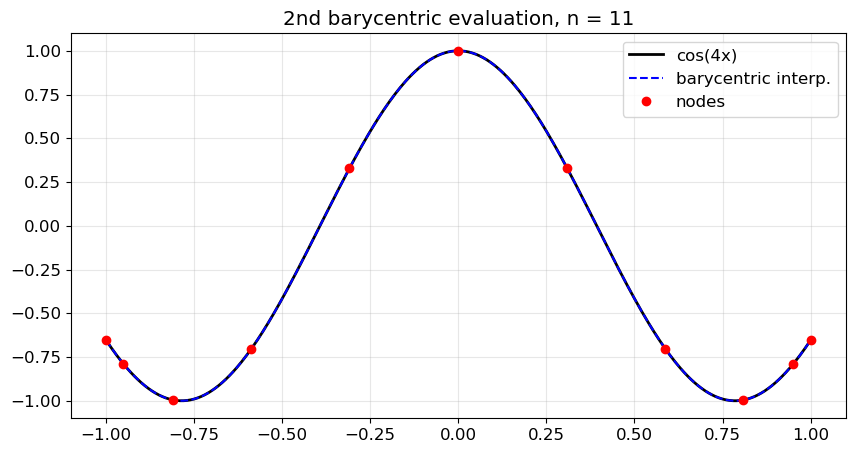

Max error on fine grid: 2.50e-05


In [8]:
# Visual check: interpolate cos(4x) at 11 nodes, evaluate on a fine grid.
n = 11
x = chebpts(n)
f = np.cos(4 * x)

yy = np.linspace(-1, 1, 401)
p_yy = barycentric(yy, x, f)

fig, ax = plt.subplots()
ax.plot(yy, np.cos(4 * yy), 'k-', lw=2, label='cos(4x)')
ax.plot(yy, p_yy, 'b--', lw=1.5, label='barycentric interp.')
ax.plot(x, f, 'ro', ms=6, label='nodes')
ax.legend(); ax.grid(alpha=0.3)
ax.set_title(f'2nd barycentric evaluation, n = {n}')
plt.show()

print(f'Max error on fine grid: {np.max(np.abs(p_yy - np.cos(4*yy))):.2e}')

## 4. Integration: Clenshaw-Curtis from coefficients

If $f \approx \sum_k c_k T_k$, then by linearity,
$$
\int_{-1}^{1} f(x)\,dx \;\approx\; \sum_{k=0}^{n-1} c_k \int_{-1}^{1} T_k(x)\,dx.
$$
And $\int_{-1}^{1} T_k = 0$ for odd $k$ (antisymmetry) and $\int_{-1}^{1} T_k = \tfrac{2}{1-k^2}$ for even $k\ge 0$. So integration in coefficient space is just a dot product with a fixed weight vector. The classical *Clenshaw-Curtis quadrature rule* is what you get if you re-express this dot product back in value space using the DCT.

For pedagogy we stay in coefficient space here.

In [9]:
def cheb_integrate(c):
    """Definite integral on [-1, 1] from Chebyshev coefficients."""
    n = c.size
    k = np.arange(n)
    weights = np.zeros(n)
    even = (k % 2 == 0)
    weights[even] = 2.0 / (1.0 - k[even]**2)            # 2 at k=0, then 2/(1-k^2)
    return float(c @ weights)


# Convergence on f(x) = exp(x): the integral is e - 1/e.
exact = np.exp(1) - np.exp(-1)
print("   n      I_n               error")
print("-" * 42)
for n in [4, 8, 12, 16, 20, 32]:
    c = polyfit(np.exp(chebpts(n)))
    I = cheb_integrate(c)
    print(f"  {n:3d}   {I:.15f}   {abs(I - exact):.2e}")

   n      I_n               error
------------------------------------------
    4   2.347575190325842   2.83e-03
    8   2.350402382165274   5.12e-09
   12   2.350402387287597   6.22e-15
   16   2.350402387287603   4.44e-16
   20   2.350402387287603   4.44e-16
   32   2.350402387287603   4.44e-16


### The same rule, in value space, via FFT

The coefficient-space version is the cleanest derivation, but it costs us one DCT to build the coefficients before we can take the inner product against the moment vector. In practice it is often nicer to absorb that DCT into the integration itself: the composition $\mathbf{f} \mapsto c \mapsto m^\top c$ is a single linear functional on values, and we can pre-compute its weights once and reuse them.

Concretely, for any vector of values $\mathbf{f} = (f(x_0), \ldots, f(x_{n-1}))$ at type-2 nodes, there is a vector $w$ such that
$$
\sum_{k=0}^{n-1} c_k m_k \;=\; \sum_{j=0}^{n-1} w_j\, f_j,
$$
where $m_k = \int_{-1}^{1} T_k(x)\,dx$. The classical formula (Waldvogel 2006) computes $w$ in $O(n\log n)$ via a single FFT of a mirrored moment sequence.

These are the *Clenshaw-Curtis weights*. Once you have them, integration is just a dot product against the values, no DCT required at evaluation time.

In [ ]:
from scipy.fft import ifft

def clenshaw_curtis_weights(n):
    """Value-space Clenshaw-Curtis weights via one FFT (Waldvogel 2006)."""
    if n == 1:
        return np.array([2.0])
    k = np.arange(2, n, 2)
    c = np.concatenate([[2.0], 2.0 / (1.0 - k**2)])
    half = n // 2
    c = np.concatenate([c, c[1: half][::-1]])
    w = ifft(c).real
    w[0] *= 0.5
    return np.concatenate([w, [w[0]]])


def cheb_integrate_values(f):
    """Definite integral on [-1, 1] from values at type-2 Chebyshev nodes."""
    return float(clenshaw_curtis_weights(f.size) @ f)


# Cross-check: the two routes give the same answer.
print("   n     coeff-space         value-space         |diff|")
print("-" * 62)
for n in [4, 8, 12, 16, 20, 32]:
    f = np.exp(chebpts(n))
    I_coef = cheb_integrate(polyfit(f))
    I_vals = cheb_integrate_values(f)
    print(f"  {n:3d}   {I_coef:.15f}   {I_vals:.15f}   {abs(I_coef - I_vals):.2e}")

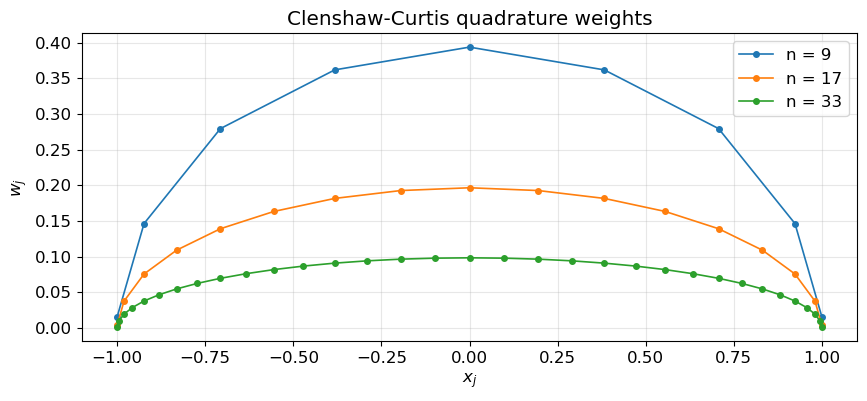

In [11]:
# Picture: the weights cluster mass towards the center, compensating for the
# nodes themselves clustering towards the endpoints.
fig, ax = plt.subplots(figsize=(10, 4))
for n in [9, 17, 33]:
    x = chebpts(n)
    w = clenshaw_curtis_weights(n)
    ax.plot(x, w, 'o-', lw=1.2, ms=4, label=f'n = {n}')
ax.set_xlabel('$x_j$')
ax.set_ylabel('$w_j$')
ax.set_title('Clenshaw-Curtis quadrature weights')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

## 5. Differentiation: the coefficient recurrence

If $f(x) = \sum_{k=0}^{N} c_k T_k(x)$, then $f'(x) = \sum_{k=0}^{N-1} c_k' T_k(x)$ where the coefficients $c_k'$ satisfy the **Chebyshev derivative recurrence**
$$
c_{k-1}' \;=\; c_{k+1}' \;+\; 2k\, c_k, \qquad k = N, N-1, \ldots, 1,
$$
with $c_N' = c_{N+1}' = 0$, and a final correction $c_0' \leftarrow c_0' / 2$.

Two things to notice:

1. The map $c \mapsto c'$ is **linear**, just $c' = D_N c$, where $D_N$ is a sparse upper-triangular matrix. So differentiation really is a linear operator on coefficient space.
2. Working in coefficient space avoids the catastrophic ill-conditioning of forming a value-space differentiation matrix and inverting it. The recurrence is $O(n)$ and stable.

The vectorised implementation below uses two cumulative sums (one for the even sub-sequence, one for the odd) to evaluate the recurrence in $O(n)$ work and no explicit Python loop.

In [ ]:
def cheb_diff_coeffs(c):
    """Chebyshev coefficients of f' from those of f."""
    n = c.size
    if n <= 1:
        return np.zeros(1)
    cout = np.zeros(n - 1)
    t = 2.0 * np.arange(1, n) * c[1:]                  # 2k * c_k, for k = 1, ..., n-1
    cout[n-2::-2] = np.cumsum(t[n-2::-2])
    cout[n-3::-2] = np.cumsum(t[n-3::-2])
    cout[0] *= 0.5
    return cout


# Smoke test: differentiate sin(2 pi x) and compare with 2 pi cos(2 pi x).
n = 33
x = chebpts(n)
c  = polyfit(np.sin(2 * np.pi * x))
cp = cheb_diff_coeffs(c)
fp_grid = polyval(np.concatenate([cp, [0.0]]))         # pad to length n for polyval on the same grid
fp_true_nodes = 2 * np.pi * np.cos(2 * np.pi * x)
print(f"max error on grid: {np.max(np.abs(fp_grid - fp_true_nodes)):.2e}")

# Fine grid for smooth reference curves.
xx = np.linspace(-1, 1, 401)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(xx, np.sin(2 * np.pi * xx), 'k-', lw=2, label=r'$f(x) = \sin(2\pi x)$')
axes[0].plot(x, fp_grid, 'ro', ms=4, label="Chebyshev $f'$ at nodes")
axes[0].plot(xx, 2 * np.pi * np.cos(2 * np.pi * xx), 'b-', lw=1, alpha=0.6,
             label=r"exact $f'(x) = 2\pi\cos(2\pi x)$")
axes[0].set_xlabel('x'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title('Function and derivative')

axes[1].semilogy(x, np.abs(fp_grid - fp_true_nodes) + 1e-18, 'ro-', ms=4)
axes[1].axhline(np.finfo(float).eps, color='gray', ls='--', alpha=0.5,
                label='machine epsilon')
axes[1].set_xlabel('x'); axes[1].set_ylabel(r"$|f'_{cheb} - f'_{exact}|$")
axes[1].set_title('Pointwise error at the nodes')
axes[1].legend(); axes[1].grid(alpha=0.3, which='both')
plt.tight_layout(); plt.show()

## 6. Adaptive sampling and a simple chop

We have all the linear primitives. The remaining question is *where to stop*: how many Chebyshev coefficients are enough? The pragmatic answer:

1. Sample $f$ at $n$ points; transform to coefficients.
2. Look at the tail $|c_k|$ for $k$ near $n-1$.
3. If the tail has decayed past a target tolerance, chop it off. Otherwise, double $n$ and try again.

An industrial-strength version called `standardChop` (Aurentz-Trefethen 2017) looks for a *plateau* in the coefficient envelope. We implement a much simpler version that captures the right idea without the bells and whistles.

:::{note} Algorithm: simple_chop

Given coefficients $c_0, \ldots, c_{n-1}$ and a tolerance $\tau$:

1. Form the **monotonic envelope from the right**: $e_k = \max_{j\ge k} |c_j|$.
2. Normalize: $\hat e_k = e_k / e_0$.
3. If a non-trivial tail of $\hat e$ (say the last 10% of indices) is still above $\tau$, declare unhappy and return the full vector.
4. Otherwise return the last index $k^\star$ with $\hat e_{k^\star} > \tau$.

Both the envelope step and the *tail*-based unhappiness check matter. Real coefficient sequences are noisy on top of a smooth decaying trend, and chopping at the first sub-tolerance entry is too aggressive. Even worse: parity-symmetric functions have exact zeros at every other index, so checking only the very last coefficient against $\tau$ would rubber-stamp under-resolved odd or even functions.
:::

In [13]:
def simple_chop(c, tol=1e-13):
    """Trim a Chebyshev coefficient vector below a relative tolerance.

    A pedagogical stand-in for the standardChop algorithm. Good enough for the
    well-resolved smooth functions that come up in this notebook; for
    sketchy inputs use the real thing.
    """
    c = np.asarray(c, dtype=float)
    n = c.size
    if n <= 1:
        return c.copy()
    cmax = np.max(np.abs(c))
    if cmax == 0.0:
        return np.zeros(1)
    env = np.maximum.accumulate(np.abs(c[::-1]))[::-1] / cmax
    # Require the tail (last ~10%) of the envelope to be below tol. A single
    # zero at the very end (e.g. from parity symmetry) is not convincing.
    tail = max(3, n // 10)
    if env[n - tail] > tol:
        return c.copy()
    keep = np.where(env > tol)[0]
    if keep.size == 0:
        return np.zeros(1)
    return c[: keep[-1] + 1].copy()


def chebfit_adaptive(f, tol=1e-13, n_min=17, n_max=2**14):
    """Sample f and double n until the coefficient tail is below tol."""
    n = n_min
    while n <= n_max:
        c = polyfit(f(chebpts(n)))
        c_trim = simple_chop(c, tol)
        if c_trim.size < n:
            return c_trim
        n = 2 * n - 1                                  # nested doubling: n_new uses old grid + midpoints
    return c                                           # not converged; return the best we have

In [14]:
examples = [
    ('exp(x)',          lambda x: np.exp(x)),
    ('1/(1+25 x^2)',    lambda x: 1.0 / (1 + 25 * x**2)),
    ('cos(50 x)',       lambda x: np.cos(50 * x)),
    ('|x|^5',           lambda x: np.abs(x)**5),
]
for label, f in examples:
    c = chebfit_adaptive(f)
    print(f"  {label:<18s}  resolved with {c.size:5d} coefficients")

  exp(x)              resolved with    13 coefficients
  1/(1+25 x^2)        resolved with   153 coefficients
  cos(50 x)           resolved with    87 coefficients
  |x|^5               resolved with   387 coefficients


## 7. Bolting it together: a tiny `Cheb` class

Now the payoff. With those five primitives, we can wrap a function in an object that supports:

- evaluation at arbitrary points,
- pointwise addition, subtraction, scalar multiplication (the vector-space operations),
- pointwise multiplication of two `Cheb` objects (with a strong caveat below).

For the linear functional and operator we expose **module-level functions** rather than methods, in the spirit of `np.sum`, `np.diff`, `np.inner`:

| Free function | Role |
|---|---|
| `chebsum(f)` | $\int_{-1}^{1} f$, the linear functional |
| `chebdiff(f)` | $f'$, the linear operator |
| `chebinner(f, g)` | $\langle f, g \rangle = \int f g$ |
| `chebnorm(f)` | $\|f\|_2 = \sqrt{\langle f, f\rangle}$ |

The standalone form makes the parallel with NumPy explicit: just as `np.sum(arr)` is a functional on vectors, `chebsum(f)` is a functional on functions. Rootfinding and general affine intervals $[a,b]$ are deliberately left out. They are the next layer up and require either a colleague-matrix eigenvalue solve or a small amount of bookkeeping for the affine map.

In [ ]:
class Cheb:
    """A function on [-1, 1] represented by its Chebyshev coefficients."""

    def __init__(self, coeffs):
        self.c = np.asarray(coeffs, dtype=float).copy()

    @classmethod
    def from_callable(cls, f, tol=1e-13):
        return cls(chebfit_adaptive(f, tol=tol))

    @property
    def n(self):
        return self.c.size

    # ----- evaluation -----
    def __call__(self, y):
        f = polyval(self.c)
        x = chebpts(self.n)
        return barycentric(y, x, f)

    # ----- vector-space operations -----
    def __add__(self, other):
        if np.isscalar(other):
            d = self.c.copy(); d[0] += other; return Cheb(d)
        a, b = _align(self.c, other.c)
        return Cheb(a + b)

    def __sub__(self, other):
        return self + (-1.0) * other if not np.isscalar(other) else self + (-other)

    def __mul__(self, other):
        if np.isscalar(other):
            return Cheb(other * self.c)
        return _multiply_pointwise(self, other)

    __radd__ = __add__
    __rmul__ = __mul__

    def __repr__(self):
        return f'Cheb(n={self.n}, ||c||_inf={np.max(np.abs(self.c)):.2e})'


def _align(a, b):
    """Zero-pad two coefficient vectors to the same length."""
    n = max(a.size, b.size)
    A = np.zeros(n); A[: a.size] = a
    B = np.zeros(n); B[: b.size] = b
    return A, B


def _multiply_pointwise(f, g, tol=1e-13):
    """Multiply two Cheb objects in value space on a 2x oversampled grid.

    Cheap and cheerful. See the warning below for the limitations.
    """
    n = 2 * max(f.n, g.n)
    x = chebpts(n)
    fg = f(x) * g(x)                                   # values of the product
    return Cheb(simple_chop(polyfit(fg), tol=tol))


# ---------- numpy-style free functions on Cheb ----------
def chebsum(f):
    """Definite integral of f on [-1, 1]. Analogue of np.sum."""
    return cheb_integrate(f.c)


def chebdiff(f):
    """Derivative of f as a new Cheb. Analogue of np.diff."""
    return Cheb(cheb_diff_coeffs(f.c))


def chebinner(f, g):
    r"""L^2 inner product $\langle f, g \rangle = \int_{-1}^{1} f g \,dx$. Analogue of np.inner."""
    return chebsum(f * g)


def chebnorm(f):
    r"""L^2 norm $\|f\|_2 = \sqrt{\langle f, f \rangle}$. Analogue of np.linalg.norm."""
    return float(np.sqrt(chebinner(f, f)))

### A note on `__mul__`

Multiplication is the first operation that leaves the polynomial space we started in. If $f$ has degree $d_f$ and $g$ has degree $d_g$, then $fg$ has degree $d_f + d_g$, so we need a finer grid to sample the product without aliasing.

We do the cheapest possible thing: sample both factors on a grid of length $2\max(n_f, n_g)$, multiply pointwise, and run `polyfit` on the values. Since $2\max(n_f, n_g) \ge n_f + n_g$, polynomial multiplication is captured exactly when both factors are already polynomials of those lengths.

:::{warning}
**This is a deliberately naive implementation.** Two ways it can go wrong, both worth being aware of:

1. The factor of 2 is enough for *polynomial* multiplication, but if either `Cheb` is itself only a truncation of a smoother underlying function, the product can have non-trivial high-frequency content that the coarse grid does not see. The output may then look fine on the grid but disagree with the true product off-grid.
2. We chop the result with `simple_chop`, which inherits all the limitations of §6. A genuinely under-resolved product may silently appear "happy".

A robust implementation should oversample adaptively (sample, transform, check the tail, refine if needed) and chop with `standardChop`.
:::

In [16]:
# Quick sanity check: sin^2 + cos^2 = 1, and sin*cos = 0.5*sin(2x).
s = Cheb.from_callable(lambda x: np.sin(np.pi * x))
c = Cheb.from_callable(lambda x: np.cos(np.pi * x))

one = s * s + c * c
print(f"||sin^2 + cos^2 - 1||_inf  = {np.max(np.abs(one(np.linspace(-1, 1, 401)) - 1.0)):.2e}")

prod = s * c
ref  = Cheb.from_callable(lambda x: 0.5 * np.sin(2 * np.pi * x))
yy = np.linspace(-1, 1, 401)
print(f"||sin*cos - 0.5 sin(2pi x)||_inf = {np.max(np.abs(prod(yy) - ref(yy))):.2e}")
print(f"sin*cos resolved with {prod.n} coefficients (s.n = {s.n}, c.n = {c.n})")

||sin^2 + cos^2 - 1||_inf  = 1.24e-14
||sin*cos - 0.5 sin(2pi x)||_inf = 6.11e-15
sin*cos resolved with 26 coefficients (s.n = 20, c.n = 19)


### Linear algebra on functions, in practice

A few exercises that use only the primitives we just built. Each one is a one- or two-liner.

In [ ]:
# Build a few functions.
f = Cheb.from_callable(lambda x: np.exp(x))
g = Cheb.from_callable(lambda x: np.sin(np.pi * x))
h = 2.0 * f - g                                       # pointwise linear combination

print(f, g, h)

# Evaluate on a fine grid and compare with the closed form.
yy = np.linspace(-1, 1, 401)
true = 2 * np.exp(yy) - np.sin(np.pi * yy)
print(f"||h - true||_inf = {np.max(np.abs(h(yy) - true)):.2e}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yy, f(yy), 'k-', lw=1.5, label=r'$f(x) = e^x$')
ax.plot(yy, g(yy), 'b-', lw=1.5, label=r'$g(x) = \sin(\pi x)$')
ax.plot(yy, h(yy), 'r-', lw=2, label=r'$h = 2f - g$')
ax.plot(yy, true, 'r--', lw=1, alpha=0.6, label='exact $2e^x - \\sin(\\pi x)$')
ax.set_xlabel('x'); ax.set_title('Pointwise linear combination of Cheb objects')
ax.legend(); ax.grid(alpha=0.3)
plt.show()

In [ ]:
# (i) Differentiation as a linear operator: (f - g)' = f' - g'.
lhs = chebdiff(f - g)
rhs = chebdiff(f) - chebdiff(g)
print(f"||(f-g)' - (f' - g')||_inf = {np.max(np.abs(lhs(yy) - rhs(yy))):.2e}")

# (ii) The fundamental theorem of calculus, sanity version.
fp = chebdiff(f)                                      # f'(x) = e^x
I_fp = chebsum(fp)                                    # int_-1^1 f' = f(1) - f(-1) = e - 1/e
print(f"int f'  = {I_fp:.15f}")
print(f"f(1)-f(-1) = {np.exp(1) - np.exp(-1):.15f}")

# (iii) L^2 inner product: <sin(pi x), sin(pi x)> = 1.
print(f"<sin(pi x), sin(pi x)> = {chebinner(g, g):.15f}     (exact: 1.0)")
print(f"||sin(pi x)||_2        = {chebnorm(g):.15f}     (exact: 1.0)")

# (iv) Orthogonality of sin(pi x) and cos(pi x) on [-1, 1].
g2 = Cheb.from_callable(lambda x: np.cos(np.pi * x))
print(f"<sin(pi x), cos(pi x)> = {chebinner(g, g2):.2e}     (exact: 0)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: derivative linearity, both sides agree on a fine grid.
axes[0].plot(yy, lhs(yy), 'k-',  lw=2,   label=r"$(f-g)'$")
axes[0].plot(yy, rhs(yy), 'r--', lw=1.2, label=r"$f' - g'$")
axes[0].set_xlabel('x'); axes[0].set_title("Differentiation is linear")
axes[0].legend(); axes[0].grid(alpha=0.3)

# Right: orthogonality of sin(pi x) and cos(pi x), and their pointwise product.
axes[1].plot(yy, g(yy),       'b-', lw=1.5, label=r'$\sin(\pi x)$')
axes[1].plot(yy, g2(yy),      'g-', lw=1.5, label=r'$\cos(\pi x)$')
axes[1].fill_between(yy, g(yy) * g2(yy), color='C3', alpha=0.25,
                     label=r'$\sin(\pi x)\cos(\pi x)$ (signed area = 0)')
axes[1].axhline(0, color='k', lw=0.5)
axes[1].set_xlabel('x'); axes[1].set_title('Orthogonality on $[-1, 1]$')
axes[1].legend(loc='lower left'); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### Differentiation matrix on coefficient space

Because `cheb_diff_coeffs` is linear, its action is a matrix. Reading it off explicitly makes the structure visible: $D_N$ is upper triangular with a sparse pattern that depends only on parity. This same matrix is what gets assembled into spectral discretisations of boundary value problems.

[[ 0.  1.  0.  3.  0.  5.  0.  7.]
 [ 0.  0.  4.  0.  8.  0. 12.  0.]
 [ 0.  0.  0.  6.  0. 10.  0. 14.]
 [ 0.  0.  0.  0.  8.  0. 12.  0.]
 [ 0.  0.  0.  0.  0. 10.  0. 14.]
 [ 0.  0.  0.  0.  0.  0. 12.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. 14.]]


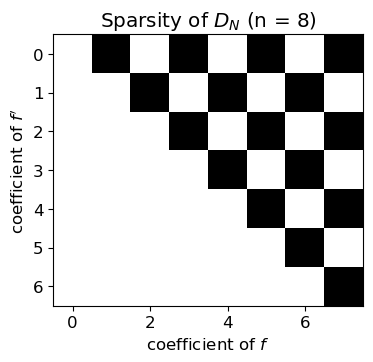

In [19]:
def diff_matrix(n):
    """The (n-1) x n matrix mapping coefficients of f to those of f'."""
    D = np.zeros((n - 1, n))
    for k in range(n):
        e = np.zeros(n); e[k] = 1.0
        D[:, k] = cheb_diff_coeffs(e)
    return D

D = diff_matrix(8)
with np.printoptions(precision=1, suppress=True):
    print(D)

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(D != 0, cmap='gray_r')
ax.set_title(r'Sparsity of $D_N$ (n = 8)')
ax.set_xlabel('coefficient of $f$')
ax.set_ylabel("coefficient of $f'$")
plt.show()

## 8. What is missing?

We have built about half of a usable Chebyshev library. The sequel that we did not write here:

- **Robust multiplication of `Cheb` objects.** Our pointwise version works on the textbook examples but oversamples by a fixed factor and then chops. A proper implementation oversamples *adaptively* and chops with `standardChop`.
- **General intervals $[a,b]$.** A linear map $x \mapsto \tfrac{b-a}{2} x + \tfrac{a+b}{2}$ takes the canonical $[-1,1]$ machinery to any interval. The integration weight picks up a Jacobian $\tfrac{b-a}{2}$.
- **Robust chop.** Our `simple_chop` is fine for textbook examples but oblivious to the *plateau* phenomenon that real coefficient sequences exhibit. See the Aurentz-Trefethen paper.
- **Rootfinding.** Roots of $\sum c_k T_k$ are eigenvalues of the *colleague matrix* of $c$, and clipped to those that fall in $[-1,1]$.
- **BVPs.** Spectral collocation reuses the differentiation matrix from §7 and adds boundary rows. Once you have that, eigenvalue problems and nonlinear BVPs are within reach.

But all of those build on the same primitives we wrote in this notebook. Once you can convert between values and coefficients, evaluate by barycentric, integrate by Clenshaw-Curtis, differentiate by the recurrence, multiply pointwise on a finer grid, and chop sensibly, the rest of the library is a matter of organising bookkeeping.